## **Task 3 — Data Visualization**

This notebook presents visual analysis of the cleaned E-Commerce Sales dataset using Python. The visualizations focus on sales performance, customer activity, product performance, geographic distribution, and monthly trends.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/online_retail_cleaned.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (22044, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SalesAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


1. Top 10 products

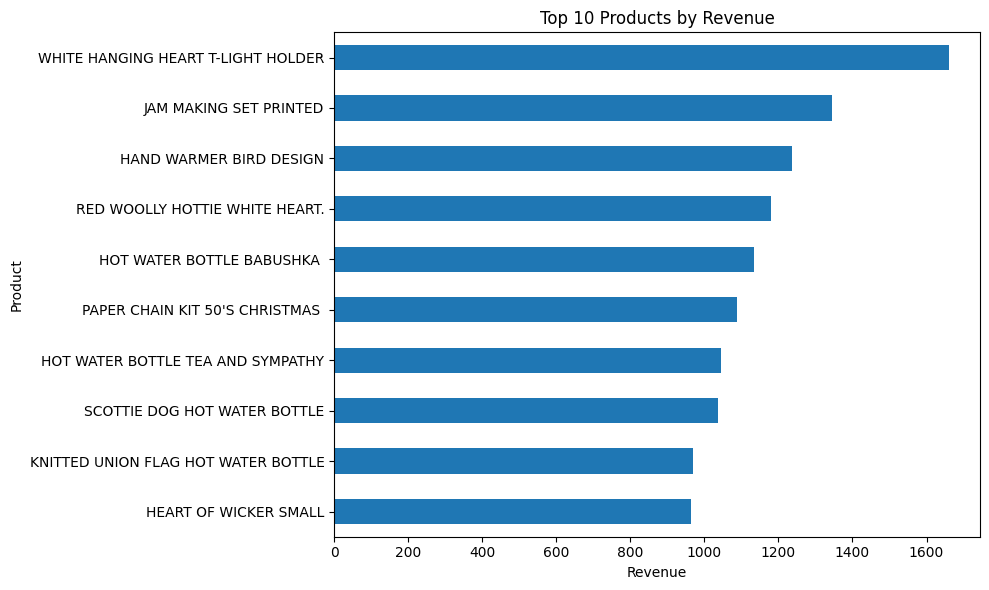

In [ ]:
top_products = (
    df.groupby("Description")["SalesAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))

top_products.plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

2. Top 10 countries by Revenue

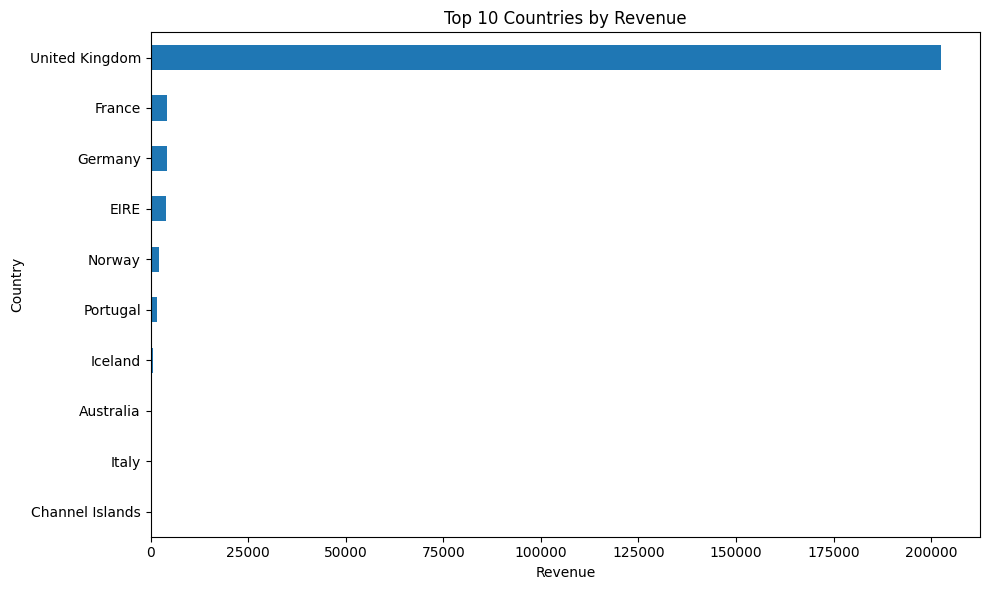

In [ ]:
top_countries = (
    df.groupby("Country")["SalesAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))

top_countries.plot(kind="barh")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

3. Monthly Order Trend

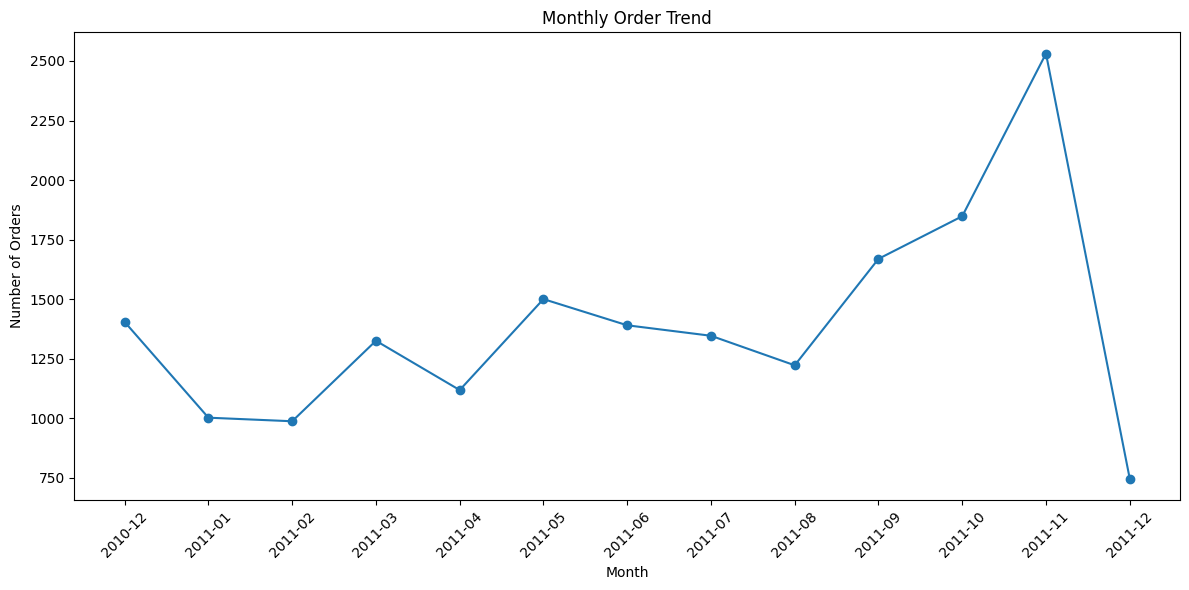

In [ ]:
monthly_orders = (
    df.groupby(df["InvoiceDate"].dt.to_period("M"))["InvoiceNo"]
      .nunique()
      .reset_index()
)

monthly_orders["InvoiceDate"] = monthly_orders["InvoiceDate"].astype(str)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_orders["InvoiceDate"],
    monthly_orders["InvoiceNo"],
    marker="o"
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

4. Top 10 Countries by Number of Orders

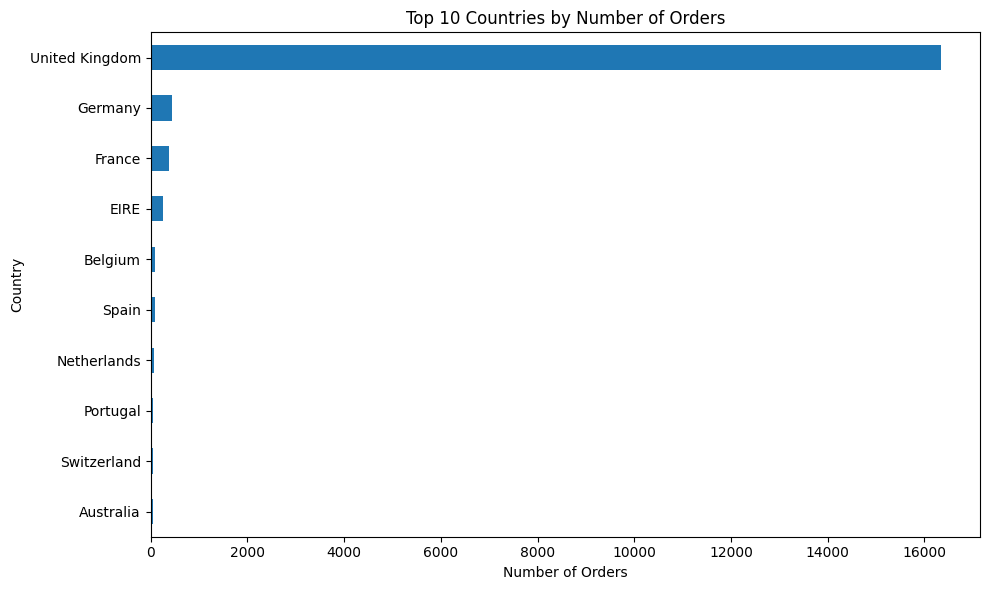

In [ ]:
country_orders = (
    df.groupby("Country")["InvoiceNo"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
      .sort_values()
)

plt.figure(figsize=(10, 6))

country_orders.plot(kind="barh")

plt.title("Top 10 Countries by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

5. Top 10 customers by Revenue

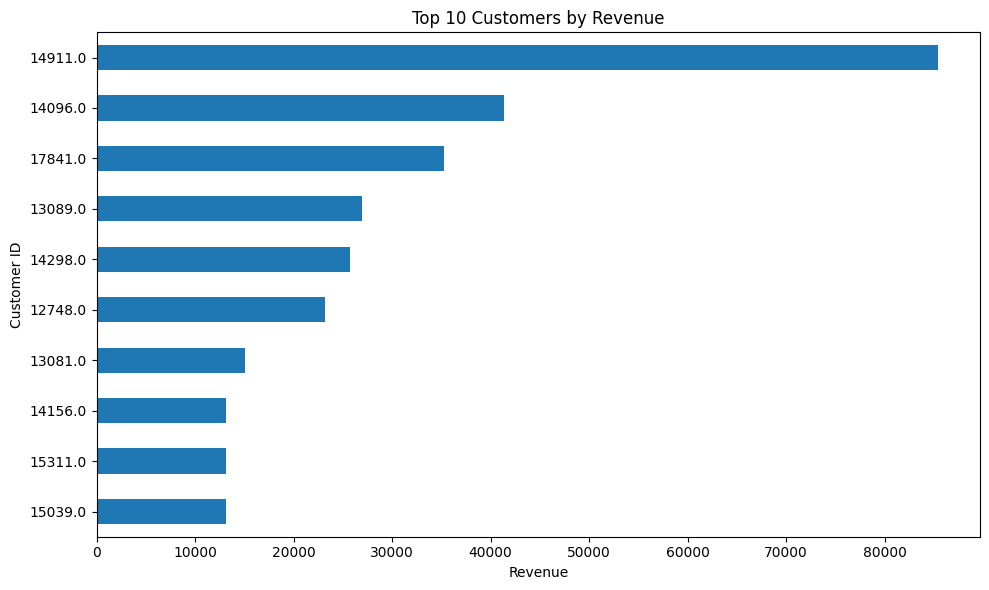

In [ ]:
customer_sales = (
    df.dropna(subset=["CustomerID"])
      .groupby("CustomerID")["SalesAmount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .sort_values()
)

plt.figure(figsize=(10, 6))

customer_sales.plot(kind="barh")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.show()

6. Quantities Distribution

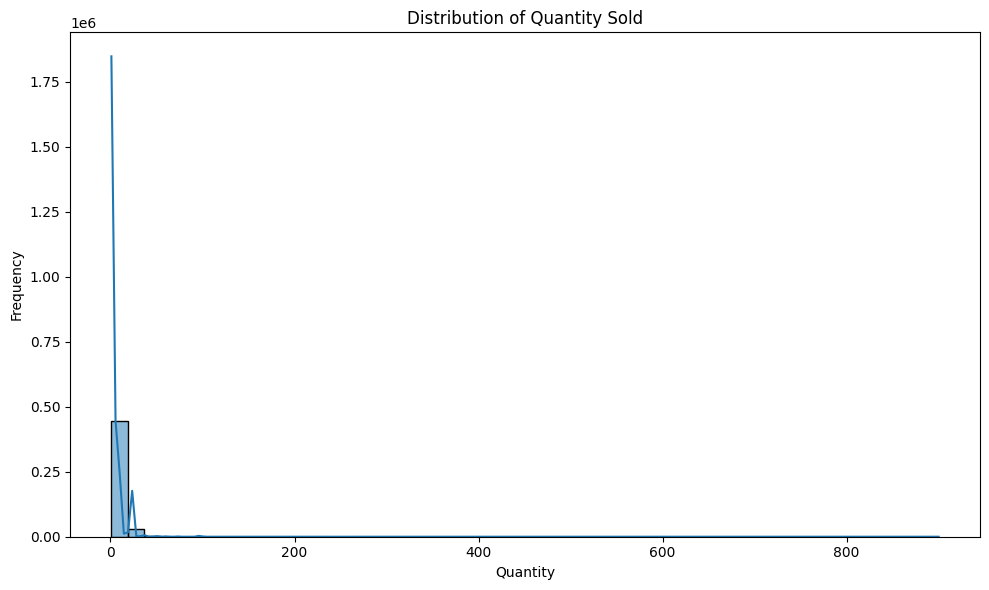

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Quantity"],
    bins=50,
    kde=True
)

plt.title("Distribution of Quantity Sold")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

7. Sales amount Distribution

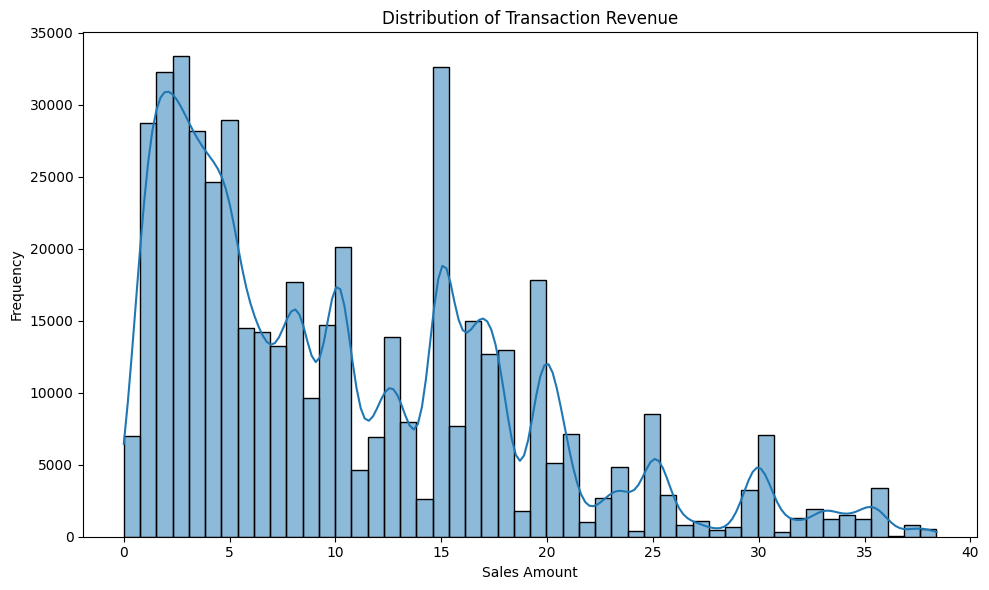

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["SalesAmount"],
    bins=50,
    kde=True
)

plt.title("Distribution of Transaction Revenue")
plt.xlabel("Sales Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

8. Quantity vs Sales Amount

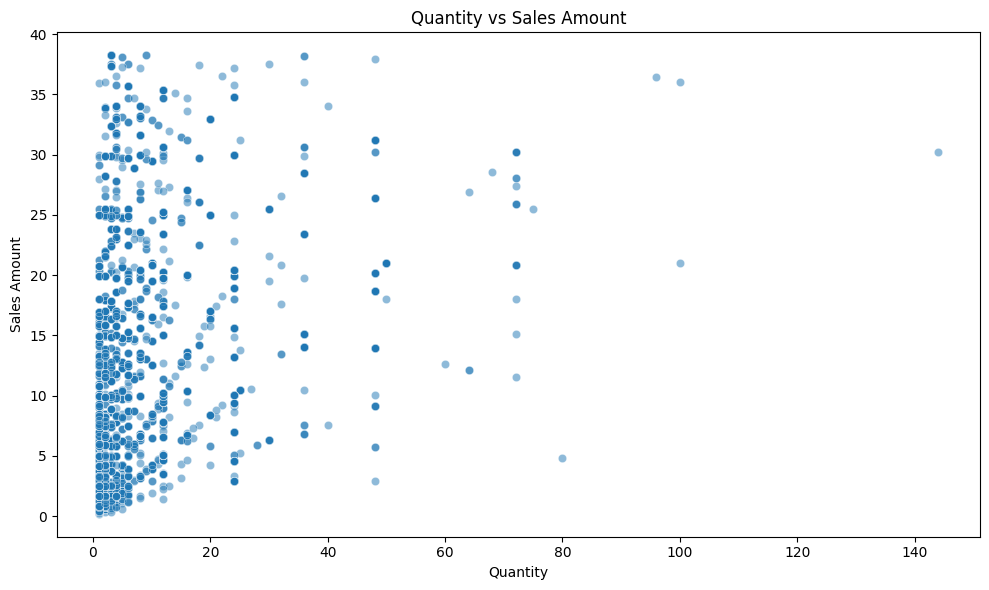

In [ ]:
sample_df = df.sample(
    n=min(10000, len(df)),
    random_state=42
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sample_df,
    x="Quantity",
    y="SalesAmount",
    alpha=0.5
)

plt.title("Quantity vs Sales Amount")
plt.xlabel("Quantity")
plt.ylabel("Sales Amount")
plt.tight_layout()
plt.show()

9. Monthly Revenue Trend

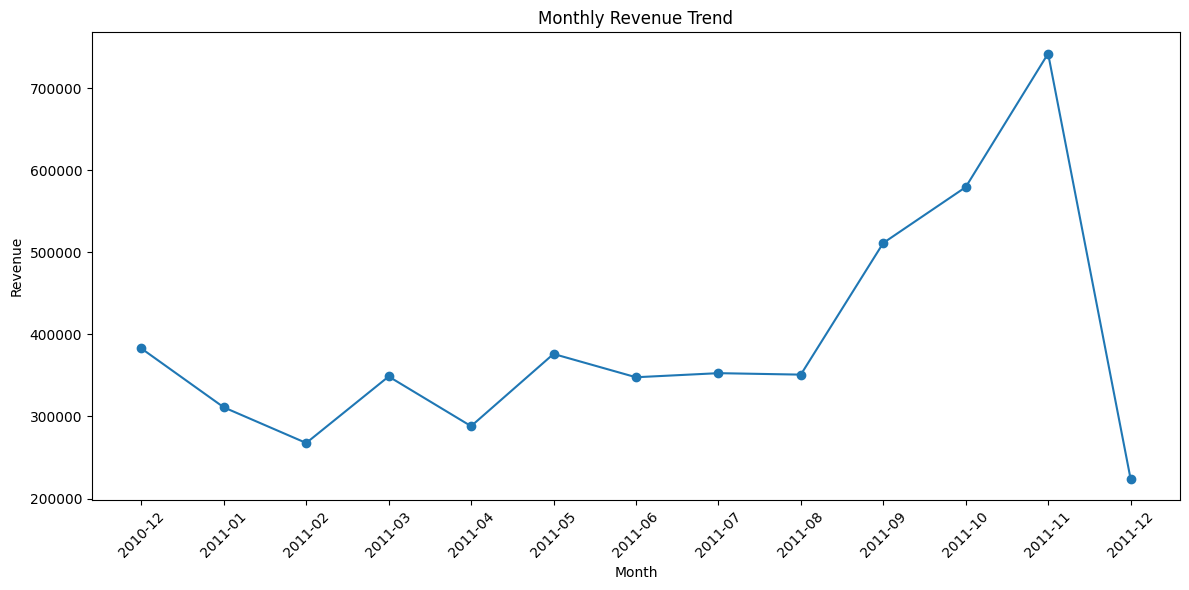

In [ ]:
monthly_revenue = (
    df.groupby(df["InvoiceDate"].dt.to_period("M"))["SalesAmount"]
      .sum()
      .reset_index()
)

monthly_revenue["InvoiceDate"] = (
    monthly_revenue["InvoiceDate"].astype(str)
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["InvoiceDate"],
    monthly_revenue["SalesAmount"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

10. Correlation Matrix

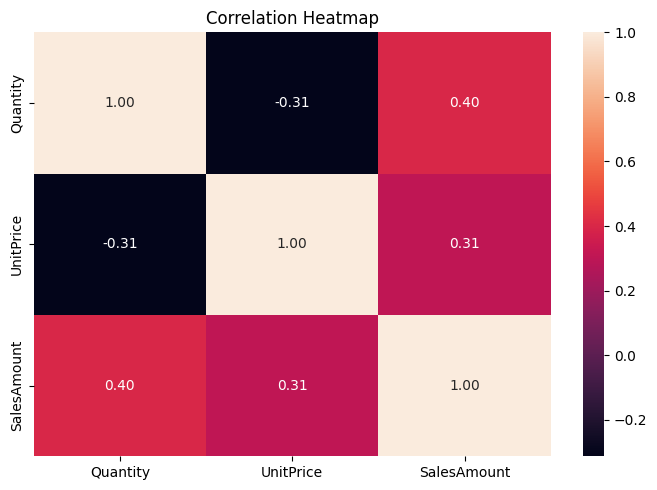

In [ ]:
numeric_cols = [
    "Quantity",
    "UnitPrice",
    "SalesAmount"
]

correlation = df[numeric_cols].corr()

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()